In [1]:
import pandas as pd
import pyterrier as pt
if not pt.started():
    pt.init()
import numpy as np
from transformers import AutoTokenizer
from tqdm import tqdm
import torch
import sys
sys.path.append("./lsr_package/")
from lsr.transformer import LSR
from pyterrier.model import add_ranks
from ir_measures import *
import matplotlib.pyplot as plt

/tmp/ipykernel_186/2943069062.py:3: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():
Java started and loaded: pyterrier.java, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_186/2943069062.py:4: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()
/opt/miniconda3/envs/tmp/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
There was a problem when trying to write in your cache folder (/root/.cache/huggingface/hub). You should set the

In [2]:
print("Hello")

Hello


In [3]:
results = pd.read_csv("./oracle_runs/results.csv")
results = results.sort_values("name")

In [48]:
results

,name,nDCG@10,sens_docs@10
3,1,0.431889,1.169811
365,1,0.431889,1.169811
417,4,NaN,NaN
179,4,NaN,NaN
256,11,0.418597,1.018868
...,...,...,...
5944,30481,0.012674,0.896226
5948,30491,0.012480,1.009434
5947,30501,0.002727,0.990566
5949,30511,0.003073,1.056604


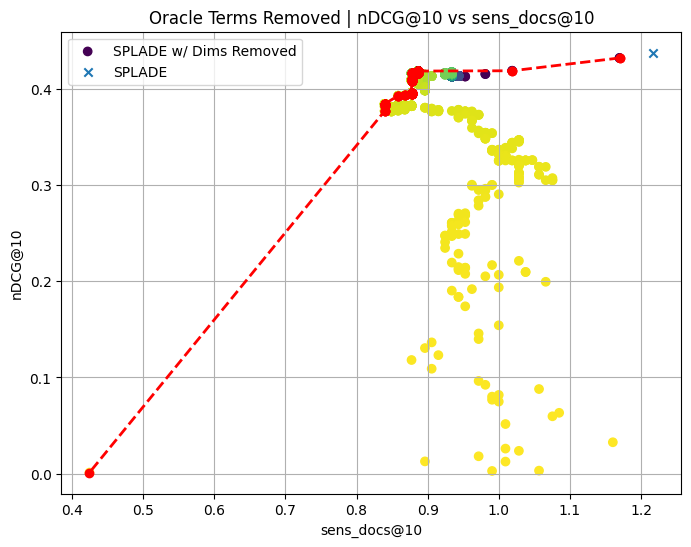

,name,nDCG@10,sens_docs@10
3,1.0,0.431889,1.169811
365,1.0,0.431889,1.169811
256,11.0,0.418597,1.018868
11,11.0,0.418597,1.018868
5001,25661.0,0.418292,0.886792
...,...,...,...
5774,28641.0,0.376857,0.839623
5618,28641.0,0.376857,0.839623
5616,28631.0,0.376842,0.839623
5809,28631.0,0.376842,0.839623


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Identify Pareto optimal points
def find_pareto_front(df):
    # Sort by high nDCG@10 and low sens_docs@10
    sorted_df = df.sort_values(by=['nDCG@10', 'sens_docs@10'], ascending=[False, True])

    pareto_front = []
    current_best_sens = np.inf  # Track lowest sens_docs@10 seen so far

    for _, row in sorted_df.iterrows():
        if row["sens_docs@10"] <= current_best_sens:  # Pareto optimal condition
            pareto_front.append(row)
            current_best_sens = row["sens_docs@10"]

    # Return the Pareto optimal points as a DataFrame
    return pd.DataFrame(pareto_front)

# Assuming 'results' is your DataFrame
pareto_points_df = find_pareto_front(results)

# Create the plot
plt.figure(figsize=(8, 6))
# Scatter plot for Pareto optimal points
plt.scatter(pareto_points_df["sens_docs@10"], pareto_points_df["nDCG@10"], color='red', zorder=3)
# Line connecting the Pareto optimal points
plt.plot(pareto_points_df["sens_docs@10"], pareto_points_df["nDCG@10"], color='red', linestyle='--', linewidth=2)
# Scatter plot for all points in the results
plt.scatter(results["sens_docs@10"], results["nDCG@10"], alpha=1, c=results["name"], cmap="viridis", label="SPLADE w/ Dims Removed")
# Highlight a specific point
plt.scatter(1.216981, 0.437492, marker="x", label="SPLADE")

# Labels and title
plt.grid()
plt.legend()
plt.xlabel("sens_docs@10")
plt.ylabel("nDCG@10")
plt.title("Oracle Terms Removed | nDCG@10 vs sens_docs@10")

# Show the plot
plt.show()

# Return the Pareto optimal points DataFrame
pareto_points_df


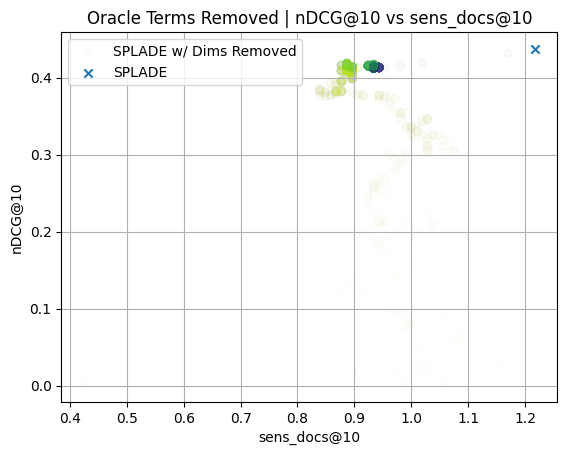

In [10]:
# plt.figure(figsize=(8, 6))
plt.scatter(results["sens_docs@10"], results["nDCG@10"], alpha=0.01, c=results["name"], cmap="viridis", label = "SPLADE w/ Dims Removed")
plt.scatter(1.216981, 0.437492, marker = "x", label = "SPLADE")
# Labels and title
plt.xlabel("sens_docs@10")
plt.ylabel("nDCG@10")
plt.title("Oracle Terms Removed | nDCG@10 vs sens_docs@10")

# Grid for better readability
plt.grid(True)
plt.legend()

# Show the plot
# plt.savefig("./plots/oracle_terms_removed.png", dpi = 1080)
plt.show()

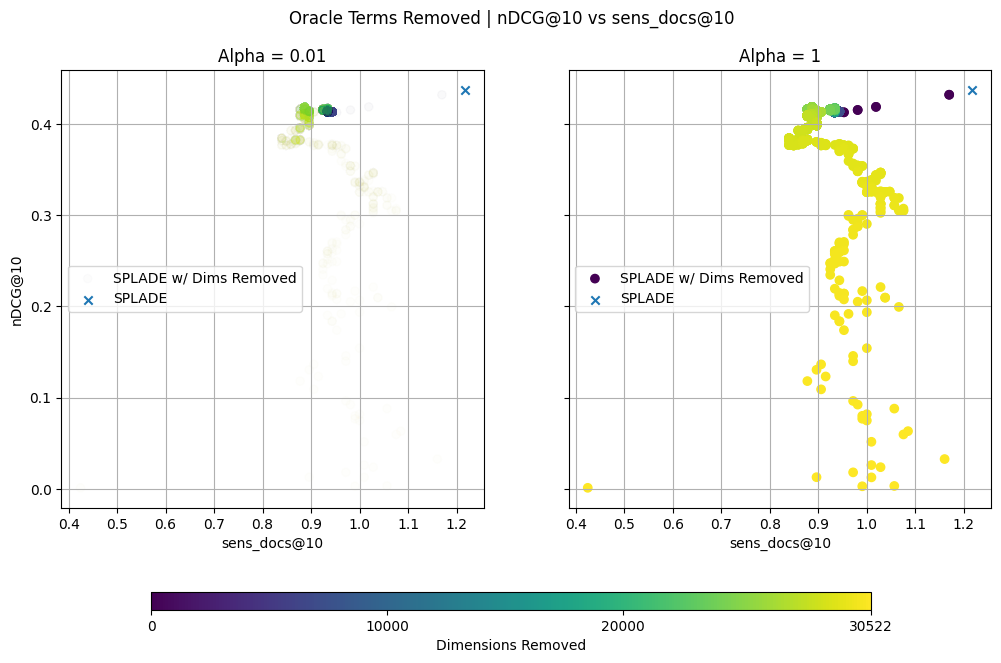

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

# First plot with alpha = 0
axes[0].scatter(results["sens_docs@10"], results["nDCG@10"], alpha=0.01, c=results["name"], cmap="viridis", label="SPLADE w/ Dims Removed")
axes[0].scatter(1.216981, 0.437492, marker="x", label="SPLADE")
axes[0].set_xlabel("sens_docs@10")
axes[0].set_ylabel("nDCG@10")
axes[0].set_title("Alpha = 0.01")
axes[0].grid(True)
axes[0].legend()

# Second plot with alpha = 0.5
sc2 = axes[1].scatter(results["sens_docs@10"], results["nDCG@10"], alpha=1, c=results["name"], cmap="viridis", label="SPLADE w/ Dims Removed")
axes[1].scatter(1.216981, 0.437492, marker="x", label="SPLADE")
axes[1].set_xlabel("sens_docs@10")
axes[1].set_title("Alpha = 1")
axes[1].grid(True)
axes[1].legend()

cbar_ax = fig.add_axes([0.2, -0.02, 0.6, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(sc2, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Dimensions Removed")
cbar.set_ticks([0, 10000, 20000, 30522])  # Key reference points

plt.suptitle("Oracle Terms Removed | nDCG@10 vs sens_docs@10")
# plt.tight_layout()

plt.subplots_adjust(bottom=0.15)  # Adjust to avoid clipping colorbar
plt.savefig("./plots/oracle_terms_removed_2_alphas.png", dpi=100, bbox_inches="tight")
plt.show()

In [56]:
# Removing what terms makes a big difference?


docs = pd.read_pickle("/nfs/primary/sas_reranker/ohsumed_docs_w_t5base_sensitivity.pkl")
queries = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/queries.pkl")
qrels = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/qrels.pkl")

sensitive_texts = docs[docs["sensitivity"] == 1].text.tolist()
non_sensitive_texts = docs[docs["sensitivity"] == 0].text.tolist()

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

vocab_size = len(tokenizer.vocab)
sensitive_frequency_matrix = np.zeros((len(sensitive_texts), vocab_size), dtype=int)
non_sensitive_frequency_matrix = np.zeros((len(non_sensitive_texts), vocab_size), dtype=int)

for i, text in tqdm(enumerate(sensitive_texts), total = len(sensitive_texts), desc = "Tokenizing"):
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    sensitive_frequency_matrix[i], _ = np.histogram(token_ids, bins=np.arange(vocab_size + 1))

for i, text in tqdm(enumerate(non_sensitive_texts), total = len(non_sensitive_texts), desc = "Tokenizing"):
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)
    non_sensitive_frequency_matrix[i], _ = np.histogram(token_ids, bins=np.arange(vocab_size + 1))

oracle_vector = sensitive_frequency_matrix.sum(axis = 0) - non_sensitive_frequency_matrix.sum(axis = 0)

Tokenizing: 100%|██████████| 12649/12649 [00:09<00:00, 1367.32it/s]


In [79]:
results_cleaned = results.dropna(subset=['nDCG@10'])

results_cleaned['gap_nDCG'] = results_cleaned['sens_docs@10'].diff()

top_10_gaps = results_cleaned.sort_values('gap_nDCG', ascending=False).head(10)

values = top_10_gaps[['name', 'nDCG@10', 'gap_nDCG']].name.tolist()
top_10_gaps

/tmp/ipykernel_186/1935168019.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_cleaned['gap_nDCG'] = results_cleaned['sens_docs@10'].diff()


,name,nDCG@10,sens_docs@10,gap_nDCG
5914,30441,0.032560,1.160377,0.150943
5948,30491,0.012480,1.009434,0.113208
5864,30071,0.221078,1.028302,0.094340
5881,30141,0.209548,1.037736,0.094340
5912,30411,0.063162,1.084906,0.084906
5911,30361,0.087856,1.056604,0.075472
5901,30341,0.096252,0.971698,0.066038
5949,30511,0.003073,1.056604,0.066038
5725,29221,0.346542,1.028302,0.047170
5895,30261,0.154090,1.000000,0.047170


In [105]:
def get_tokens_with_highest_weights(oracle_vector, tokenizer, start_rank, end_rank):
    """
    Get the tokens with the highest weights from the oracle vector between the `start_rank`-th 
    and `end_rank`-th highest weights.

    Parameters:
    - oracle_vector: A numpy array or list of weights corresponding to each token in the vocabulary.
    - tokenizer: The BERT tokenizer.
    - start_rank: The rank of the starting weight (inclusive, 1-indexed).
    - end_rank: The rank of the ending weight (inclusive, 1-indexed).
    
    Returns:
    - A list of tuples containing the token and its corresponding weight in the specified rank range.
    """
    # Ensure oracle_vector is a numpy array for easy handling
    oracle_vector = np.array(oracle_vector)
    
    # Get indices of the sorted weights in descending order
    sorted_indices = np.argsort(oracle_vector)[::-1]
    
    # Get the tokens corresponding to the sorted indices
    tokens = tokenizer.convert_ids_to_tokens(sorted_indices)
    
    # Get the specified range of tokens and their weights
    result_tokens = [tokens[i] for i in range(start_rank-1, end_rank)]
    
    return result_tokens

get_tokens_with_highest_weights(oracle_vector, tokenizer, 0, 10)

# Initialize an empty list to store tokens
token_matrix = []

# Loop through each value in the list
for value in values:
    # Generate the range (value-10) to value inclusive
    token_range = list(range(value-10, value+1))
    print(get_tokens_with_highest_weights(oracle_vector, tokenizer, value - 10, value + 1))
    print()

['##ma', 'blood', '##ym', '##ph', '##id', 'syndrome', 'cell', "'", '6', '##uro', 'more', '##to']

['these', '2', ';', 'treatment', 'are', '##l', 'after', 'not', 'this', 'had', '1', 'from']

['trans', 'sc', 'cerebral', '##ren', 'complications', '##cos', 'they', 'chemotherapy', '13', '##py', '##x', '##cal']

['##3', 'lower', 'men', '##tension', 'day', 'cho', 'block', 'cardiac', '##rot', '##gno', 'o', 'its']

['which', 'levels', '##cino', '##tic', 'pain', 'cancer', 'has', 'cells', '##oma', 'intra', 'other', 'hem']

['##ing', '##cy', 'i', '##pa', 'diagnosis', 'most', 'mg', '##ry', '##y', '##io', 'e', 'age']

['rate', '##lo', '##re', 'their', '##tis', '##bo', '##co', '##or', 'g', 'also', '##ct', 'subjects']

['by', 'that', 'or', 'is', '##s', '%', 'for', 'were', 'was', 'patients', 'a', 'with']

['##po', 'sex', '##len', 'continuous', 'abdominal', 'cs', 'metabolic', 'pattern', 'week', '##usion', 'mega', 'then']

['data', 'days', 'changes', '##um', 'ci', 'ex', '##g', '##p', '##pathy', 'c', 'ang